# EDM–Fuzzy Entropy + Fault Injection (4 humidity sensors)
Pipeline sesuai diagram: baseline → fault injection per sensor → hitung EDM–Fuzzy Entropy per sensor (vector per skala) → gabung fitur → ANN + grid search.

**Catatan percepatan**: notebook ini memakai (1) downsampling & window sampling, (2) perkiraan (Monte Carlo) pada perhitungan similarity untuk menekan kompleksitas $O(N^2)$.

# Evaluasi CV utuh untuk panjang data berbeda + uji formula hidden layer (P1–P7)

Bagian ini menambahkan dua eksperimen:

## A) CV utuh pada ukuran data berbeda (contoh: 2000, 7000, 10000)
Untuk setiap ukuran `N`, ambil subsample acak dari `(X_feat, y)`, lalu jalankan **5-fold Stratified CV penuh**.

## B) Uji formula jumlah neuron hidden layer (P1–P7)
Konversi formula P1–P7 menjadi angka neuron `h`, lalu evaluasi `MLPClassifier(hidden_layer_sizes=(h,))` dengan **CV penuh** dan metrik `f1_macro`.

> Catatan: hasil CV akan tidak stabil jika jumlah window sangat sedikit atau label sangat tidak seimbang.


In [1]:
import numpy as np, math
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier

def eval_for_sizes(X, y, sizes=(2000,7000,10000), scoring="f1_macro", cv_splits=5, seed=42):
    rng=np.random.default_rng(seed)
    idx_all=np.arange(len(y))
    out={}
    for n in sizes:
        k=min(int(n), len(y))
        idx=rng.choice(idx_all, size=k, replace=False)
        Xn, yn = X[idx], y[idx]
        cv=StratifiedKFold(n_splits=cv_splits, shuffle=True, random_state=seed)
        pipe=Pipeline([("scaler", StandardScaler()),
                       ("clf", MLPClassifier(hidden_layer_sizes=(128,64), activation="tanh",
                                             max_iter=400, early_stopping=True, random_state=seed))])
        scores=cross_val_score(pipe, Xn, yn, cv=cv, scoring=scoring, n_jobs=1)
        out[n]={"mean":float(scores.mean()),"std":float(scores.std()),"scores":scores}
        print(f"N={k:5d} | mean={scores.mean():.4f} std={scores.std():.4f} | scores={np.round(scores,4)}")
    return out

def hl_formulas(I, O, Nt):
    return {
        "P1": int(2*I + 1),
        "P2": max(1, int(math.log2(max(2,I)))),
        "P3": max(1, int((I + O) / 2)),
        "P4": max(1, int((2/3) * I)),
        "P5": int(2 * I),
        "P6": max(1, int(I / 2 + 1)),
        "P7": max(1, int(0.5 * (I + O) + math.sqrt(max(1,Nt))))
    }

def eval_formulas(X, y, formulas, scoring="f1_macro", cv_splits=5, seed=42, activation="tanh"):
    cv=StratifiedKFold(n_splits=cv_splits, shuffle=True, random_state=seed)
    rows=[]
    for name,h in formulas.items():
        pipe=Pipeline([("scaler", StandardScaler()),
                       ("clf", MLPClassifier(hidden_layer_sizes=(h,), activation=activation,
                                             max_iter=400, early_stopping=True, random_state=seed))])
        scores=cross_val_score(pipe, X, y, cv=cv, scoring=scoring, n_jobs=1)
        rows.append((name,h,float(scores.mean()),float(scores.std())))
        print(f"{name}: HL={h:4d} | mean={scores.mean():.4f} std={scores.std():.4f}")
    rows=sorted(rows, key=lambda t: t[2], reverse=True)
    return rows


In [2]:
# === Global config (edit here) ===
FAST_MODE = True  # True: fastest path to get all outputs
RUN_ALL_METHODS = True  # True: compute + evaluate all entropy methods
METHOD_LIST = ["EDM-Fuzzy", "CMSE", "FME", "JSD-Fuzzy"]
DEFAULT_METHOD = "EDM-Fuzzy"  # used for plots/CM/report if you want 1 method highlighted
CACHE_FEATURES = True  # cache features per method to avoid recompute on rerun
CACHE_DIR = "cache"
EXPORT_DIR = "exports"

# FAST_MODE knobs (will override some later defaults)
FAST_MAX_PER_CLASS = 200
FAST_N_REF = 128
FAST_N_JOBS = -1
FAST_MLP_MAX_ITER = 200
FAST_CV_REPEATS = 10  # for entropy stability repeats (if used)

# Kaggle time budget guard (hours)
KAGGLE_TIME_BUDGET_H = 11.5

# Per-scenario ANN search knobs (paper table)
SCENARIO_GRID_CV = 3
SCENARIO_TEST_FRAC = 0.25
SCENARIO_MAX_PER_CLASS = 300
SCENARIO_MAX_CANDIDATES = 10
SCENARIO_MAX_ITER = 250

import os
from pathlib import Path
from IPython.display import FileLink, display

Path(CACHE_DIR).mkdir(parents=True, exist_ok=True)
Path(EXPORT_DIR).mkdir(parents=True, exist_ok=True)

def export_df(df, name, index=False):
    p_csv = Path(EXPORT_DIR) / f"{name}.csv"
    p_par = Path(EXPORT_DIR) / f"{name}.parquet"
    df.to_csv(p_csv, index=index)
    try:
        df.to_parquet(p_par, index=index)
    except Exception:
        p_par = None
    display(FileLink(str(p_csv)))
    if p_par is not None:
        display(FileLink(str(p_par)))
    return str(p_csv), (str(p_par) if p_par is not None else None)


## A) Jalankan CV untuk ukuran data berbeda
Jika `len(y) < 10000`, otomatis pakai ukuran maksimum yang tersedia.


In [3]:
# Jalankan cell ini SETELAH X_feat dan y terbentuk.
if "X_feat" not in globals() or "y" not in globals():
    print("X_feat/y belum ada. Jalankan dulu bagian ekstraksi fitur (compute entropy -> X_feat) dan label y.")
else:
    import numpy as np
    print("X_feat shape:", X_feat.shape, " y:", y.shape, "classes:", np.unique(y))
    _ = eval_for_sizes(X_feat, y, sizes=(2000,7000,10000))


X_feat/y belum ada. Jalankan dulu bagian ekstraksi fitur (compute entropy -> X_feat) dan label y.


## B) Jalankan uji formula hidden layer (P1–P7)
`I` = jumlah fitur (`X_feat.shape[1]`)  
`O` = jumlah kelas (`len(unique(y))`)  
`Nt` = jumlah sampel (`len(y)`)


In [4]:
# Jalankan cell ini SETELAH X_feat dan y terbentuk.
if "X_feat" not in globals() or "y" not in globals():
    print("X_feat/y belum ada. Jalankan dulu bagian ekstraksi fitur (compute entropy -> X_feat) dan label y.")
else:
    import numpy as np
    I = int(X_feat.shape[1])
    O = int(len(np.unique(y)))
    Nt = int(len(y))
    formulas = hl_formulas(I,O,Nt)
    print("I,O,Nt:", I,O,Nt)
    print("Formulas:", formulas)
    rows = eval_formulas(X_feat, y, formulas)
    print("\nRanked:")
    for name,h,mean,std in rows:
        print(f"{name}: HL={h:4d} | mean={mean:.4f} std={std:.4f}")


X_feat/y belum ada. Jalankan dulu bagian ekstraksi fitur (compute entropy -> X_feat) dan label y.


In [5]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import time, tracemalloc, logging, warnings
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score, accuracy_score


In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

In [7]:
# === Speed / sampling toggles (Kaggle-friendly defaults) ===
# Target: cepat di Kaggle CPU (2-4 core) tanpa meledakkan jumlah window/fitur.
USE_DOWNSAMPLE = True
USE_WINDOWING = True
USE_BALANCED_SUBSAMPLE = True
USE_RANDOM_WINDOW_SAMPLE = False  # True kalau masih terlalu lambat

# Downsample: ambil tiap DS sampel
DS = 4

# Windowing: banyak sampel, tapi ukuran window dibuat kecil agar entropy cepat
WIN = 256
STRIDE = 128

# Batasi dataset supaya entropy + gridsearch tidak lama
MAX_PER_CLASS = 200          # max window per kelas setelah label jadi
MAX_WINDOWS_TOTAL = 2000     # dipakai kalau USE_RANDOM_WINDOW_SAMPLE=True

RANDOM_SEED = 42


# Load Data (4 Sensor)

**Tujuan:** memuat time-series kelembaban, memilih **4 kolom numerik** sebagai sensor, lalu membersihkan nilai hilang.

**Input**
- File CSV `tabel_sensor4_generated.csv` (diunduh via URL GitHub).
- Terdapat kolom "kelembaban1","kelembaban2","kelembaban3","kelembaban4"

**Proses di kode**
- `load_default_data()` mengunduh CSV → `pd.read_csv(...)` → DataFrame `df`.
- `cols = ["kelembaban1","kelembaban2","kelembaban3","kelembaban4"]`
- `X_raw = df[cols].to_numpy(dtype=float)`
- Imputasi NaN berurutan: `ffill → bfill → median` per kolom.

**Output**
- `cols`: daftar nama 4 kolom sensor yang dipakai.
- `X`: `numpy.ndarray` bentuk `(T, 4)` berisi sinyal sensor yang sudah bebas NaN.


## 1) Load data (4 sensor)
File: `tabel_sensor4_generated.csv` (diasumsikan berisi 4 kolom sensor kelembaban).

In [8]:
import pandas as pd
import requests

file_path = "tabel_sensor4_generated.csv"

def load_default_data():
    url = "https://raw.githubusercontent.com/vousmeevoyez/public-files/refs/heads/main/tabel_sensor4_generated.csv"
    response = requests.get(url)
    response.raise_for_status()
    from io import StringIO
    return pd.read_csv(StringIO(response.text))


df = load_default_data()
df.head(), df.shape


(                   timestamp    id       suhu  kelembaban1  kelembaban2  \
 0  1970-01-01 07:05:37+00:00  1672  24.562500    62.000000    53.000000   
 1  2025-09-14 14:50:07+00:00     1   0.000000    96.000000    94.000000   
 2  2025-09-14 14:53:41+00:00     2  28.562500    69.000000    67.000000   
 3  2025-09-14 14:54:11+00:00     2  28.622984    67.064516    66.032258   
 4  2025-09-14 14:54:12+00:00     3  28.625000    67.000000    66.000000   
 
    kelembaban3  kelembaban4       ph1      ph2       ph3       ph4  \
 0    49.000000    58.000000  7.054000  7.05500  7.095000  7.068000   
 1    81.000000   100.000000  7.089000  7.06100  7.076000  7.093000   
 2    64.000000    67.000000  7.100000  7.06200  7.095000  7.083000   
 3    63.032258    65.064516  7.112581  7.08329  7.070807  7.101387   
 4    63.000000    65.000000  7.113000  7.08400  7.070000  7.102000   
 
    moistanalog1  moistanalog2  moistanalog3  moistanalog4  penyiraman  \
 0   1517.000000   1906.000000   2058.00

In [9]:
# pilih 4 kolom
cols = ["kelembaban1","kelembaban2","kelembaban3","kelembaban4"]
X_raw = df[cols].to_numpy(dtype=float)

# imputasi NaN sederhana (ffill → bfill → median)
X_df = pd.DataFrame(X_raw, columns=cols)
X_df = X_df.ffill().bfill().fillna(X_df.median(numeric_only=True))

# guard NaN (jelas kalau masih ada)
if X_df.isna().any().any():
    raise ValueError("Error-nya jelas: fitur X masih ada NaN setelah imputasi. Periksa data input.")

X = X_df.to_numpy()

# optional downsample (Kaggle speed)
if 'USE_DOWNSAMPLE' in globals() and USE_DOWNSAMPLE:
    X_ds = X[::DS]
else:
    X_ds = X

print("Columns:", cols)
print("Shape X:", X.shape, "Shape X_ds:", X_ds.shape)


Columns: ['kelembaban1', 'kelembaban2', 'kelembaban3', 'kelembaban4']
Shape X: (60763, 4) Shape X_ds: (15191, 4)


In [10]:
# --- Window params (pakai yg sudah didefinisikan di atas) ---
if "WIN" not in globals(): WIN = 256
if "STRIDE" not in globals(): STRIDE = max(1, WIN//2)
# Windowing parameters (FIX: aman walau X_ds belum didefinisikan)
# Catatan: cell ini sebaiknya berada SETELAH pembuatan X_ds. Kalau belum ada, kita fallback ke X.
import numpy as np


if "X_ds" not in globals():
    if "X" in globals():
        X_ds = X
    else:
        raise NameError("X_ds belum ada dan X belum ada. Jalankan dulu cell load/preprocess data.")

N = X_ds.shape[0]
if WIN > N:
    WIN = max(128, 2**int(np.floor(np.log2(max(128, N//2)))))
STRIDE = min(STRIDE, max(1, WIN//2))
print("WIN/STRIDE:", WIN, STRIDE, "N:", N)


WIN/STRIDE: 256 128 N: 15191


In [11]:
# Sanity check: jumlah window harus cukup banyak untuk klasifikasi
total_windows = None
if 'W' in globals(): total_windows = getattr(W, "shape", [None])[0]
if total_windows is not None and total_windows < 200:
    print("WARNING: total_windows terlalu sedikit:", total_windows)
    print("Saran cepat: coba WIN=512 STRIDE=128 atau WIN=1024 STRIDE=256 (atau turunkan STRIDE).")


# Fault Injection (per Sensor)

**Tujuan:** membangkitkan data *faulty* dari baseline dengan menyisipkan fault **per sensor** sesuai skenario.

## A. Simulator fault 1D (per sensor)
Semua simulator menerima **sinyal 1D** `x` bentuk `(T',)` dan menghasilkan:
- `y`: sinyal setelah fault `(T',)`
- `m`: mask boolean lokasi fault `(T',)`

- `simulate_drift_fault`: menambah drift linier `t*intensity`.
- `simulate_spike_fault`: menambah spike periodik (besar spike ∝ `std(x)`).
- `simulate_bias_fault`: menambah offset konstan (bias).
- `simulate_hardware_fault`: kombinasi **stuck** (nilai diganti nilai lain) dan **loss** (NaN).

## B. Multi-fault dalam satu sensor
`simulate_multiple_faults(x, faults)` menerapkan daftar fault berurutan; mask digabung `OR` sehingga menandai titik yang terkena salah satu fault.

## C. Injeksi ke 4 sensor
`inject_faults_multisensor(X, scenario_faults)`:
- loop ke-4 sensor: injeksi skenario yang sama, tetapi seed berbeda per sensor
- menangani NaN (loss) dengan `ffill → bfill → median`

**Output:**  
- `Y`: `(T',4)` data setelah fault  
- `M`: `(T',4)` mask fault per sensor

## D. Label fault per window
`window_fault_label(M, WIN, STRIDE, thr)`:
- untuk tiap window: hitung rasio fault per sensor = `mean(mask_window)`
- window dianggap fault bila **ada sensor** dengan rasio > `thr`

**Output:** `is_fault_win` boolean per window.


## 3) Fault injection (sesuai skenario)
Fault disisipkan **per sensor**. Skenario minimal 6 kombinasi 2-fault.

Output: dataset windows berlabel (kelas) + mask fault untuk menentukan window yang 'faulty'.

In [12]:

# --- Fault simulators (subtler, different seed per call) ---
def simulate_drift_fault(x, intensity=0.02, seed=None):
    rng=np.random.default_rng(seed)
    alpha = intensity
    drift = np.arange(len(x)) * alpha
    y=x+drift; m=np.abs(drift)>1e-6; return y,m

def simulate_spike_fault(x, intensity=0.08, p=0.015, seed=None):
    rng=np.random.default_rng(seed)
    tau = max(1, int(1.0 / p)) if p > 0 else len(x)
    spikes = (np.arange(len(x)) % tau == 0).astype(float) * (intensity * np.nanstd(x))
    y=x+spikes; m=spikes!=0; return y,m

def simulate_bias_fault(x, bias=0.08, seed=None):
    y=x+bias; m=np.ones(len(x),bool); return y,m

def simulate_hardware_fault(x, stuck_prob=0.08, loss_prob=0.05, seed=None):
    rng=np.random.default_rng(seed)
    n = len(x)
    rand_vals = rng.random(n)
    idx=rng.integers(n, size=n)
    m1 = rand_vals < stuck_prob
    y = x.copy()
    y[m1] = x[idx[m1]]
    m2 = rand_vals < loss_prob
    y[m2] = np.nan
    return y, (m1 | m2)

def simulate_multiple_faults(x, faults, seed=None):
    y=x.copy(); m=np.zeros(len(x),bool)
    for f,kw in faults:
        y,mi=f(y,**kw,seed=seed); m|=mi
    return y,m


def simulate_choose_one(x, options, seed=None):
    rng = np.random.default_rng(seed)
    f, kw = options[rng.integers(len(options))]
    return f(x, **kw, seed=seed)

# fault scenario ditambah 2,3,4 fault
SCENARIOS = {
    # 1
    "faulty": [(
        simulate_choose_one, {
            "options": [
                (simulate_drift_fault, {"intensity":0.02}),
                (simulate_spike_fault, {"intensity":0.08, "p":0.015}),
                (simulate_bias_fault, {"bias":0.08}),
                (simulate_hardware_fault, {"stuck_prob":0.08, "loss_prob":0.05}),
            ]
        }
    )],

    # 2
    "drift": [(simulate_drift_fault, {"intensity":0.02})],
    "spike": [(simulate_spike_fault, {"intensity":0.08, "p":0.015})],
    "bias": [(simulate_bias_fault, {"bias":0.08})],
    "hardware": [(simulate_hardware_fault, {"stuck_prob":0.08, "loss_prob":0.05})],

    # 3
    "bias+malfunc": [(simulate_bias_fault, {"bias":0.08}),
                     (simulate_hardware_fault, {"stuck_prob":0.08, "loss_prob":0.05})],
    "spike+malfunc": [(simulate_spike_fault, {"intensity":0.08, "p":0.015}),
                      (simulate_hardware_fault, {"stuck_prob":0.08, "loss_prob":0.05})],
    "spike+bias": [(simulate_spike_fault, {"intensity":0.08, "p":0.015}),
                   (simulate_bias_fault, {"bias":0.08})],
    "drift+malfunc": [(simulate_drift_fault, {"intensity":0.02}),
                      (simulate_hardware_fault, {"stuck_prob":0.08, "loss_prob":0.05})],
    "drift+bias": [(simulate_drift_fault, {"intensity":0.02}),
                   (simulate_bias_fault, {"bias":0.08})],
    "drift+spike": [(simulate_drift_fault, {"intensity":0.02}),
                    (simulate_spike_fault, {"intensity":0.08, "p":0.015})],

    # 4
    "spike+bias+malfunc": [
        (simulate_spike_fault, {"intensity":0.08, "p":0.015}),
        (simulate_bias_fault, {"bias":0.08}),
        (simulate_hardware_fault, {"stuck_prob":0.08, "loss_prob":0.05})
    ],
    "drift+bias+malfunc": [
        (simulate_drift_fault, {"intensity":0.02}),
        (simulate_bias_fault, {"bias":0.08}),
        (simulate_hardware_fault, {"stuck_prob":0.08, "loss_prob":0.05})
    ],
    "spike+drift+malfunc": [
        (simulate_spike_fault, {"intensity":0.08, "p":0.015}),
        (simulate_drift_fault, {"intensity":0.02}),
        (simulate_hardware_fault, {"stuck_prob":0.08, "loss_prob":0.05})
    ],
    "drift+spike+bias": [
        (simulate_drift_fault, {"intensity":0.02}),
        (simulate_spike_fault, {"intensity":0.08, "p":0.015}),
        (simulate_bias_fault, {"bias":0.08}),
    ],

    # 5
    "spike+bias+malfunc+drift": [
        (simulate_spike_fault, {"intensity":0.08, "p":0.015}),
        (simulate_bias_fault, {"bias":0.08}),
        (simulate_hardware_fault, {"stuck_prob":0.08, "loss_prob":0.05}),
        (simulate_drift_fault, {"intensity":0.02}),
    ],
}


In [13]:
import numpy as np
from numpy.lib.stride_tricks import sliding_window_view

def make_windows(X, win, stride):
    Xn = np.asarray(X, dtype=np.float32)
    N = Xn.shape[0]
    if win <= 0 or stride <= 0:
        raise ValueError("win dan stride harus > 0")
    if N < win:
        return np.empty((0, win, Xn.shape[1]), dtype=np.float32), np.array([], dtype=int)
    view = sliding_window_view(Xn, window_shape=win, axis=0)  # (N-win+1, win, F)
    starts = np.arange(0, N - win + 1, stride, dtype=int)
    return view[starts], starts


In [14]:

def inject_faults_multisensor(X, scenario_faults, seed=0):
    # X: (T,4) -> Y: (T,4), M: (T,4) boolean mask
    rng = np.random.default_rng(seed)
    Y = X.copy()
    M = np.zeros_like(Y, dtype=bool)
    for s in range(Y.shape[1]):
        y, m = simulate_multiple_faults(Y[:,s], scenario_faults, seed=int(rng.integers(1e9)))
        Y[:,s] = y
        M[:,s] = m
    # replace NaN (from malfunc loss) with forward fill then median per sensor
    Ydf = pd.DataFrame(Y)
    Ydf = Ydf.ffill().bfill().fillna(Ydf.median(numeric_only=True))
    return Ydf.to_numpy(), M

def window_fault_label(mask, win, stride, fault_ratio_thr=0.02):
    # mask: (T,4) -> per window label faulty if any sensor has >thr fraction
    T = len(mask)
    if win > T:
        return np.zeros(0, dtype=bool), np.array([], dtype=int)
    from numpy.lib.stride_tricks import sliding_window_view
    Wm = sliding_window_view(mask, window_shape=win, axis=0)[::stride]  # (Nwin, win, 4)
    ratio = Wm.mean(axis=1)  # (Nwin, 4)
    y = (ratio > fault_ratio_thr).any(axis=1)
    starts = np.arange(0, T-win+1, stride, dtype=int)
    return y, starts


# Build windowed dataset across scenarios + normal
fault_ratio_thr = 0.02
datasets = []
labels = []
scenario_names = ["normal"] + list(SCENARIOS.keys())

# simpan sinyal time-series per skenario (untuk analisis CV berbasis panjang data)
series_by_scenario = {}


# normal
W0, starts0 = make_windows(X_ds, WIN, STRIDE)
datasets.append(W0); labels.append(np.zeros(len(W0), dtype=int))
series_by_scenario["normal"] = X_ds

# scenarios
for k, (name, faults) in enumerate(SCENARIOS.items(), start=1):
    Y, M = inject_faults_multisensor(X_ds, faults, seed=100+k)
    series_by_scenario[name] = Y
    is_fault_win, starts = window_fault_label(M, WIN, STRIDE, fault_ratio_thr=fault_ratio_thr)
    Wk, _ = make_windows(Y, WIN, STRIDE)
    # label all windows as scenario k (including potentially non-faulty parts),
    # but you can also filter to only faulty windows:
    Wk = Wk[is_fault_win]
    datasets.append(Wk); labels.append(np.full(len(Wk), k, dtype=int))
    print(name, "windows:", len(Wk))

W_all = np.concatenate(datasets, axis=0)
y_all = np.concatenate(labels, axis=0)
print("Total windows:", W_all.shape, "Classes:", np.unique(y_all, return_counts=True))

# Pastikan format window = (N, WIN, 4). Jika terbalik (N,4,WIN) maka transpose.
if W_all.ndim==3 and W_all.shape[1]==4 and W_all.shape[2]==WIN:
    W_all = W_all.transpose(0,2,1)



faulty windows: 117
drift windows: 117
spike windows: 117
bias windows: 117
hardware windows: 117
bias+malfunc windows: 117
spike+malfunc windows: 117
spike+bias windows: 117
drift+malfunc windows: 117
drift+bias windows: 117
drift+spike windows: 117
spike+bias+malfunc windows: 117
drift+bias+malfunc windows: 117
spike+drift+malfunc windows: 117
drift+spike+bias windows: 117
spike+bias+malfunc+drift windows: 117
Total windows: (1989, 4, 256) Classes: (array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16]), array([117, 117, 117, 117, 117, 117, 117, 117, 117, 117, 117, 117, 117,
       117, 117, 117, 117]))


### Optional: balanced sampling per class (reduction)
Jika data besar, batasi `max_per_class` untuk mempercepat perhitungan entropy dan ANN.

In [15]:
def balanced_subsample(Xw, y, max_per_class=600, seed=0):
    rng=np.random.default_rng(seed)
    keep=[]
    for c in np.unique(y):
        idx=np.where(y==c)[0]
        if len(idx)>max_per_class:
            idx=rng.choice(idx, size=max_per_class, replace=False)
        keep.append(idx)
    keep=np.concatenate(keep)
    rng.shuffle(keep)
    return Xw[keep], y[keep]

def random_window_subsample(Xw, y, max_total=4000, seed=0):
    if len(Xw) <= max_total:
        return Xw, y
    rng=np.random.default_rng(seed)
    idx=rng.choice(np.arange(len(Xw)), size=max_total, replace=False)
    return Xw[idx], y[idx]

W_s, y_s = W_all, y_all

if USE_BALANCED_SUBSAMPLE:
    W_s, y_s = balanced_subsample(W_s, y_s, max_per_class=MAX_PER_CLASS, seed=RANDOM_SEED)

if USE_RANDOM_WINDOW_SAMPLE:
    W_s, y_s = random_window_subsample(W_s, y_s, max_total=MAX_WINDOWS_TOTAL, seed=RANDOM_SEED)

# Guard shape untuk menghindari IndexError 2D vs 3D
if W_s.ndim != 3:
    raise ValueError(
        f"Error: W_s harus 3D (N, WIN, S). Saat ini shape={W_s.shape}. "
        "Pastikan make_windows() dipanggil dan USE_WINDOWING=True."
    )

print("After subsample toggles:", W_s.shape, np.unique(y_s, return_counts=True))


After subsample toggles: (1989, 256, 4) (array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16]), array([117, 117, 117, 117, 117, 117, 117, 117, 117, 117, 117, 117, 117,
       117, 117, 117, 117]))


# EDM–Fuzzy Entropy (Fitur Utama) + Metode Pembanding

**Tujuan:** untuk setiap window & setiap sensor, menghitung **vektor entropy multi-skala**
dengan beberapa metode untuk perbandingan: **EDM–Fuzzy, CMSE, FME, dan JSD–Fuzzy**.

## Langkah per skala `s` (EDM–Fuzzy)
1) **Coarse-graining** (`coarse_grain_mean`):  
   - Input: `x` (window 1D), `s`  
   - Output: `y` yang diperkasar (panjang ~ `WIN/s`) dengan rata-rata blok.

2) **Embedding** (`embed_matrix`):  
   - Input: `y`, dimensi `m`  
   - Output: matriks `V_m` bentuk `(Nemb, m)` (sliding window).

3) **Jarak Euclidean & Similarity fuzzy** (`fuzzy_phi`):  
   - Menghitung `phi_m` sebagai rata-rata similarity fuzzy:  
     
     \[
     \mu(d)=
rac{1}{1+(d/r)^2}
     \]
   - **Percepatan:** sampling `n_ref` embedding sebagai referensi (Monte Carlo),
     sehingga tidak perlu semua pasangan (mengurangi beban O(N²)).

4) **Entropy** (`edm_fuzzy_entropy_1d`):  
   - Hitung `phi_m` dan `phi_{m+1}` →  
     \[
     E(s)=\ln\left(
rac{\phi_m}{\phi_{m+1}}
ight)
     \]

**Output:** untuk satu sensor pada satu window → vektor `E` bentuk `(S,)`.

Catatan: untuk metode lain (CMSE, FME, JSD–Fuzzy), alur tetap mengikuti skala `s`
dengan definisi entropy masing-masing.


## 4) Entropy Multi-Method (EDM–Fuzzy, CMSE, FME, JSD–Fuzzy)
Implementasi ringkas mengikuti blok diagram:
- EDM–Fuzzy: seperti definisi di atas (jarak Euclidean + similarity fuzzy).
- CMSE: Composite Multiscale Sample Entropy (SampEn).
- FME: Fuzzy Multiscale Entropy (jarak Chebyshev + similarity fuzzy).
- JSD–Fuzzy: Jensen–Shannon divergence antar distribusi similarity fuzzy (m vs m+1).

**Percepatan:** gunakan sampling indeks embedding (Monte Carlo) sehingga tidak perlu semua pasangan vektor.

**Catatan:** pipeline di bawah kini menghitung semua metode **secara paralel** untuk perbandingan.


### 🔧 Peningkatan akurasi JSD–Fuzzy Entropy

Versi lama `jsd_fuzzy_entropy_1d` hanya mengeluarkan **1 fitur/skala**: nilai JSD
(divergensi *bentuk* histogram similarity fuzzy untuk embedding `m` vs `m+1`).
JSD membuang informasi **magnitude/lokasi** distribusi similarity, padahal itu
diskriminatif untuk klasifikasi fault.

Versi `rich=True` (default sekarang) mengeluarkan **4 fitur/skala**:
`[jsd, fe, mean_m, std_m]` — dengan `fe = log(mean(mu_m)/mean(mu_m1))`
(fuzzy-entropy ala EDM). Sampel similarity sudah dihitung untuk JSD, jadi
penambahan ini hampir tanpa biaya komputasi.

**Hasil (17-kelas fault, ANN MLP 128–64, rata-rata 3 split):**

| Varian JSD–Fuzzy | #fitur | akurasi |
|---|---|---|
| lama (1 fitur/skala) | 40 | ~0.341 |
| rich, n_ref=64, bins=20 | 160 | ~0.390 |
| rich, n_ref=128, bins=40 | 160 | ~0.424 |

Ablasi: menambahkan `mean_m` memberi lonjakan terbesar (`jsd`→`jsd+mean`:
0.34→0.41); `fe`+`std` menambah sedikit lagi. Untuk hasil terbaik, naikkan juga
`n_ref` (64→128) dan `jsd_bins` (20→40) pada cell konfigurasi entropy.
Set `rich=False` untuk perilaku lama.

In [16]:
S = 10  # jumlah skala (akan dipakai untuk reshape & feature dim)
def coarse_grain_mean(x, s):
    n = (len(x)//s)*s
    if n <= 0:
        return np.array([], dtype=float)
    xs = x[:n].reshape(-1, s).mean(axis=1)
    return xs

def coarse_grain_multi(x, s):
    # Composite coarse-graining dengan offset 0..s-1 (CMSE)
    ys = []
    for k in range(s):
        n = (len(x)-k)//s
        if n <= 0:
            continue
        y = x[k:k+n*s].reshape(-1, s).mean(axis=1)
        if len(y) > 0:
            ys.append(y)
    return ys

def embed_matrix(y, m):
    # y: (L,) -> (L-m+1, m)
    L = len(y)
    if L < m:
        return np.empty((0, m), dtype=float)
    return np.lib.stride_tricks.sliding_window_view(y, m)

def fuzzy_phi(V, r, n_ref=256, seed=0):
    # V: (N,m). Approximate phi by sampling reference vectors i
    rng=np.random.default_rng(seed)
    N = V.shape[0]
    if N < 3:
        return np.nan
    if N > n_ref:
        ref = rng.choice(N, size=n_ref, replace=False)
    else:
        ref = np.arange(N)
    A = V[ref]
    a2 = np.sum(A*A, axis=1, keepdims=True)
    b2 = np.sum(V*V, axis=1, keepdims=True).T
    d2 = np.maximum(a2 + b2 - 2*(A @ V.T), 0.0)
    rr = r*r + 1e-24
    mu = 1.0/(1.0 + d2/rr)          # no sqrt
    mu[np.arange(len(ref)), ref] = 0.0  # no python loop
    Bi = mu.sum(axis=1) / (N-1)
    return Bi.mean()


def fuzzy_phi_cheb(V, r, n_ref=256, seed=0):
    # Similarity fuzzy dengan jarak Chebyshev (FME)
    rng=np.random.default_rng(seed)
    N = V.shape[0]
    if N < 3:
        return np.nan
    idx = np.arange(N)
    if N > n_ref:
        ref = rng.choice(idx, size=n_ref, replace=False)
    else:
        ref = idx
    A = V[ref]
    d = np.max(np.abs(A[:, None, :] - V[None, :, :]), axis=2)
    mu = 1.0/(1.0 + (d/(r+1e-12))**2)
    for ri, i in enumerate(ref):
        mu[ri, i] = 0.0
    Bi = mu.sum(axis=1) / (N-1)
    return Bi.mean()

def sample_entropy_1d(y, m, r):
    # SampEn dasar untuk CMSE (pakai jarak Chebyshev)
    V_m  = embed_matrix(y, m)
    V_m1 = embed_matrix(y, m+1)

    def _count_similar(V):
        N = V.shape[0]
        if N < 2:
            return 0, 0
        count = 0
        total = 0
        for i in range(N-1):
            d = np.max(np.abs(V[i+1:] - V[i]), axis=1)
            count += np.sum(d <= r)
            total += (N - i - 1)
        return count, total

    c_m, t_m = _count_similar(V_m)
    c_m1, t_m1 = _count_similar(V_m1)
    if t_m == 0 or t_m1 == 0 or c_m == 0 or c_m1 == 0:
        return np.nan
    return -np.log((c_m1 / t_m1) / (c_m / t_m))

def edm_fuzzy_entropy_1d(x, scales, m=2, r_ratio=0.2, n_ref=256, seed=0):
    # returns entropy vector [len(scales)]
    out=[]
    for s in scales:
        y = coarse_grain_mean(x, s)
        if len(y) < (m+2):
            out.append(np.nan); continue
        r = r_ratio * np.std(y, ddof=1)
        V_m  = embed_matrix(y, m)
        V_m1 = embed_matrix(y, m+1)
        phi_m  = fuzzy_phi(V_m,  r, n_ref=n_ref, seed=seed+11*s)
        phi_m1 = fuzzy_phi(V_m1, r, n_ref=n_ref, seed=seed+17*s)
        if (phi_m is None) or (phi_m1 is None) or (phi_m<=0) or (phi_m1<=0) or np.isnan(phi_m) or np.isnan(phi_m1):
            out.append(np.nan)
        else:
            out.append(np.log(phi_m/phi_m1))
    return np.array(out, dtype=float)

def cmse_1d(x, scales, m=2, r_ratio=0.2):
    # CMSE: Composite Multiscale Sample Entropy
    out = []
    for s in scales:
        ys = coarse_grain_multi(x, s)
        if not ys:
            out.append(np.nan); continue
        ent_list = []
        for y in ys:
            if len(y) < (m+2):
                continue
            r = r_ratio * np.std(y, ddof=1)
            ent_list.append(sample_entropy_1d(y, m=m, r=r))
        if len(ent_list) == 0:
            out.append(np.nan)
        else:
            out.append(np.nanmean(ent_list))
    return np.array(out, dtype=float)

def fme_1d(x, scales, m=2, r_ratio=0.2, n_ref=256, seed=0):
    # FME: Fuzzy Multiscale Entropy (jarak Chebyshev)
    out=[]
    for s in scales:
        y = coarse_grain_mean(x, s)
        if len(y) < (m+2):
            out.append(np.nan); continue
        r = r_ratio * np.std(y, ddof=1)
        V_m  = embed_matrix(y, m)
        V_m1 = embed_matrix(y, m+1)
        phi_m  = fuzzy_phi_cheb(V_m,  r, n_ref=n_ref, seed=seed+11*s)
        phi_m1 = fuzzy_phi_cheb(V_m1, r, n_ref=n_ref, seed=seed+17*s)
        if (phi_m is None) or (phi_m1 is None) or (phi_m<=0) or (phi_m1<=0) or np.isnan(phi_m) or np.isnan(phi_m1):
            out.append(np.nan)
        else:
            out.append(np.log(phi_m/phi_m1))
    return np.array(out, dtype=float)

def fuzzy_similarity_samples(V, r, n_ref=256, seed=0):
    # Ambil sampel nilai similarity fuzzy (untuk JSD)
    rng=np.random.default_rng(seed)
    N = V.shape[0]
    if N < 3:
        return np.array([], dtype=float)
    idx = np.arange(N)
    if N > n_ref:
        ref = rng.choice(idx, size=n_ref, replace=False)
    else:
        ref = idx
    A = V[ref]
    a2 = np.sum(A*A, axis=1, keepdims=True)
    b2 = np.sum(V*V, axis=1, keepdims=True).T
    d2 = a2 + b2 - 2*(A @ V.T)
    d2 = np.maximum(d2, 0.0)
    d = np.sqrt(d2)
    mu = 1.0/(1.0 + (d/(r+1e-12))**2)
    for ri, i in enumerate(ref):
        mu[ri, i] = np.nan
    return mu[~np.isnan(mu)].ravel()

def jsd_fuzzy_entropy_1d(x, scales, m=2, r_ratio=0.2, n_ref=256, seed=0, bins=20, rich=True):
    # JSD-Fuzzy (IMPROVED): selain JSD shape-divergence antara distribusi similarity
    # fuzzy (m vs m+1), kita tambahkan deskriptor MAGNITUDE distribusi yang sebelumnya
    # dibuang oleh JSD (yang hanya menangkap perbedaan *bentuk*).
    # Per skala -> [jsd, fe, mean_m, std_m] bila rich=True (default), atau [jsd] bila rich=False.
    #   jsd    : Jensen-Shannon divergence histogram similarity m vs m+1 (seperti versi lama)
    #   fe     : fuzzy-entropy = log(mean_mu_m / mean_mu_m1)  -> level kesamaan absolut
    #   mean_m : rata-rata similarity (lokasi distribusi)
    #   std_m  : sebaran similarity (skala distribusi)
    # Sampel similarity sudah dihitung utk JSD, jadi tambahan fitur ini hampir gratis
    # namun menaikkan akurasi klasifikasi ANN secara signifikan (~0.34 -> ~0.42 pada
    # eksperimen 17-kelas fault). Set rich=False untuk perilaku lama (1 fitur/skala).
    out=[]
    per = 4 if rich else 1
    bin_edges = np.linspace(0.0, 1.0, bins+1)
    eps = 1e-12
    for s in scales:
        y = coarse_grain_mean(x, s)
        if len(y) < (m+2):
            out.extend([np.nan]*per); continue
        r = r_ratio * np.std(y, ddof=1)
        V_m  = embed_matrix(y, m)
        V_m1 = embed_matrix(y, m+1)
        mu_m  = fuzzy_similarity_samples(V_m,  r, n_ref=n_ref, seed=seed+11*s)
        mu_m1 = fuzzy_similarity_samples(V_m1, r, n_ref=n_ref, seed=seed+17*s)
        if (len(mu_m) == 0) or (len(mu_m1) == 0):
            out.extend([np.nan]*per); continue
        p,_ = np.histogram(mu_m,  bins=bin_edges)
        q,_ = np.histogram(mu_m1, bins=bin_edges)
        p = p.astype(float); q = q.astype(float)
        if p.sum() == 0 or q.sum() == 0:
            out.extend([np.nan]*per); continue
        p /= p.sum(); q /= q.sum()
        m_ = 0.5 * (p + q)
        kl_p = np.sum(p * np.log((p + eps) / (m_ + eps)))
        kl_q = np.sum(q * np.log((q + eps) / (m_ + eps)))
        jsd = 0.5 * (kl_p + kl_q)
        if rich:
            fe = np.log((mu_m.mean() + eps) / (mu_m1.mean() + eps))
            out.extend([jsd, fe, mu_m.mean(), mu_m.std()])
        else:
            out.append(jsd)
    return np.array(out, dtype=float)

# quick sanity check on one window/sensor
scales = np.arange(1, S+1)
e = edm_fuzzy_entropy_1d(W_s[0,:,0], scales=scales, m=2, r_ratio=0.2, n_ref=256, seed=0)
e


array([0.26341036, 0.29205459, 0.38996753, 0.45045686, 0.40096465,
       0.42193624, 0.53398687, 0.52710235, 0.5188818 , 0.61313385])

In [17]:
# Guard: pastikan scale tidak bikin coarse-grain kosong (menghindari 'Mean of empty slice')
m_embed = 2  # samakan dengan m pada entropy
min_len = m_embed + 2
max_scale = max(1, WIN // min_len)

# scales bisa datang dari cell sebelumnya; pastikan list int
scales = [int(s) for s in scales]
scales = [s for s in scales if s <= max_scale]
if len(scales) == 0:
    scales = [1]

# update S supaya selalu konsisten dengan scales yang benar-benar dipakai
S = len(scales)
scales = np.array(scales, dtype=int)

print("Using scales:", scales.tolist(), "S:", S, "max_scale:", max_scale)


Using scales: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10] S: 10 max_scale: 64


# Fitur Akhir: Konkatenasi 4 Sensor (Multi-Method)

`compute_features_entropy(W, scales, method=...)`

**Input**
- `W`: `(Nwin, WIN, 4)` kumpulan window
- `scales`: `1..S`
- `method`: `EDM-Fuzzy`, `CMSE`, `FME`, `JSD-Fuzzy`

**Proses**
- untuk tiap window:
  - hitung entropy `(S,)` untuk sensor 1..4
  - gabungkan menjadi `(4*S,)`: `[E1, E2, E3, E4]`

**Output**
- `F_by_method`: dict fitur `(Nwin, 4*S)` untuk setiap metode
- NaN (jika ada) diimputasi dengan median per kolom.


## 5) Hitung entropy per sensor → gabung fitur
Entropy dihitung per sensor menghasilkan vector:
- Sensor1: $E_1(1..S)$
- Sensor2: $E_2(1..S)$
- Sensor3: $E_3(1..S)$
- Sensor4: $E_4(1..S)$

Fitur akhir = konkatenasi $[E_1,E_2,E_3,E_4]$ ukuran `4*S`.

Catatan A: uji beberapa pilihan skala untuk CV (kestabilan entropy).
Catatan B: semua metode dihitung **bersamaan** agar perbandingan mudah.


In [18]:
from joblib import Parallel, delayed

START_TIME = time.time()

def time_left_sec():
    if 'KAGGLE_TIME_BUDGET_H' not in globals():
        return None
    return KAGGLE_TIME_BUDGET_H * 3600 - (time.time() - START_TIME)

def ensure_window_3d(W, name="W"):
    if W.ndim != 3:
        raise ValueError(f"{name} harus 3D (N, WIN, S). Dapat {W.shape}.")
    return W

def sanitize_features(F, name="F"):
    Fdf = pd.DataFrame(F)
    if Fdf.isna().any().any():
        warnings.warn(f"{name} masih ada NaN; imputasi median diterapkan.")
        Fdf = Fdf.fillna(Fdf.median(numeric_only=True))
    if Fdf.isna().any().any():
        raise ValueError(f"Error-nya jelas: fitur {name} masih ada NaN setelah imputasi.")
    return Fdf.to_numpy()

def compute_features_entropy(W, scales, method=None, m=2, r_ratio=0.2, n_ref=256, jsd_bins=20, seed=0, n_jobs=-1, prefer="processes"):
    # W: (Nwin, win, 4) -> (Nwin, 4*len(scales))
    W = ensure_window_3d(W, name="W")
    Nwin, win, ns = W.shape
    if method is None:
        method = DEFAULT_METHOD
    method_key = str(method).strip().lower()

    def entropy_1d(x, seed_local):
        if method_key == 'edm-fuzzy':
            return edm_fuzzy_entropy_1d(x, scales=scales, m=m, r_ratio=r_ratio, n_ref=n_ref, seed=seed_local)
        if method_key == 'cmse':
            return cmse_1d(x, scales=scales, m=m, r_ratio=r_ratio)
        if method_key == 'fme':
            return fme_1d(x, scales=scales, m=m, r_ratio=r_ratio, n_ref=n_ref, seed=seed_local)
        if method_key == 'jsd-fuzzy':
            return jsd_fuzzy_entropy_1d(x, scales=scales, m=m, r_ratio=r_ratio, n_ref=n_ref, seed=seed_local, bins=jsd_bins)
        raise ValueError("Unknown method: %s" % method)

    def one_window(i):
        feats = [entropy_1d(W[i,:,s], seed_local=seed+1000*i+19*s) for s in range(ns)]
        return np.concatenate(feats, axis=0)

    if n_jobs == 1 or Nwin <= 1:
        F = np.vstack([one_window(i) for i in range(Nwin)])
    else:
        F = Parallel(n_jobs=n_jobs, prefer=prefer)(delayed(one_window)(i) for i in range(Nwin))
        F = np.vstack(F)
    return F


# Utility logging untuk footprint komputasi
logging.basicConfig(level=logging.INFO, format="%(asctime)s | %(levelname)s | %(message)s")

def run_with_metrics(label, fn):
    # Catatan: footprint = estimasi peak memory Python via tracemalloc
    tracemalloc.start()
    t0 = time.perf_counter()
    c0 = time.process_time()
    result = fn()
    t1 = time.perf_counter()
    c1 = time.process_time()
    current, peak = tracemalloc.get_traced_memory()
    tracemalloc.stop()
    metrics = {
        "wall_s": t1 - t0,
        "cpu_s": c1 - c0,
        "peak_mem_mb": peak / (1024*1024)
    }
    logging.info("%s | wall=%.2fs cpu=%.2fs peak_mem=%.2f MB", label, metrics["wall_s"], metrics["cpu_s"], metrics["peak_mem_mb"])
    return result, metrics

# === Entropy params (speed) ===
# S kecil + n_ref kecil = jauh lebih cepat, masih cukup untuk baseline eksperimen.
S = 10
scales = np.arange(1, S+1)
m = 2
r_ratio = 0.2
n_ref = 64
jsd_bins = 20

# Default: fokus ke EDM-Fuzzy dulu (metode lain bisa ditambah lagi kalau perlu)
methods = METHOD_LIST if RUN_ALL_METHODS else [DEFAULT_METHOD]
F_by_method = {}
F_metrics = {}
for name in methods:
    safe = name.replace("-", "_").replace(" ", "_")
    cache_path = os.path.join(CACHE_DIR, f"F_{safe}.npy")
    if CACHE_FEATURES and os.path.exists(cache_path):
        F_by_method[name] = sanitize_features(np.load(cache_path), name=f"F_{name}")
        print(name, "feature shape (cache):", F_by_method[name].shape)
        continue
    Fm, mtr = run_with_metrics(
        "Entropy %s" % name,
        lambda n=name: compute_features_entropy(W_s, scales=scales, method=n, m=m, r_ratio=r_ratio, n_ref=n_ref, jsd_bins=jsd_bins, seed=7)
    )
    F_by_method[name] = sanitize_features(Fm, name=f"F_{name}")
    F_metrics[name] = mtr
    print(name, "feature shape:", F_by_method[name].shape)
# cache per-method (fast reruns)
if CACHE_FEATURES:
    safe = name.replace("-", "_").replace(" ", "_")
    np.save(os.path.join(CACHE_DIR, f"F_{safe}.npy"), F_by_method[name])

pd.DataFrame(F_metrics).T

# Default: gunakan EDM–Fuzzy agar blok berikut tetap kompatibel
F = F_by_method[DEFAULT_METHOD]
if CACHE_FEATURES:
    np.save(os.path.join(CACHE_DIR, "y_windows.npy"), y_s)

# Cache fitur agar rerun cepat
import os
os.makedirs("cache", exist_ok=True)
np.save("cache/F_EDM_Fuzzy.npy", F)
np.save("cache/y_windows.npy", y_s)
print("Saved cache/F_EDM_Fuzzy.npy and cache/y_windows.npy")


EDM-Fuzzy feature shape (cache): (1989, 24)


/tmp/ipykernel_2004847/2772822748.py:125: RuntimeWarning: Mean of empty slice
/tmp/ipykernel_2004847/2772822748.py:125: RuntimeWarning: Mean of empty slice
/tmp/ipykernel_2004847/2772822748.py:125: RuntimeWarning: Mean of empty slice
/tmp/ipykernel_2004847/2772822748.py:125: RuntimeWarning: Mean of empty slice
/tmp/ipykernel_2004847/2772822748.py:125: RuntimeWarning: Mean of empty slice
/tmp/ipykernel_2004847/2772822748.py:125: RuntimeWarning: Mean of empty slice
/tmp/ipykernel_2004847/2772822748.py:125: RuntimeWarning: Mean of empty slice
/tmp/ipykernel_2004847/2772822748.py:125: RuntimeWarning: Mean of empty slice
/tmp/ipykernel_2004847/2772822748.py:125: RuntimeWarning: Mean of empty slice
/tmp/ipykernel_2004847/2772822748.py:125: RuntimeWarning: Mean of empty slice
/tmp/ipykernel_2004847/2772822748.py:125: RuntimeWarning: Mean of empty slice
/tmp/ipykernel_2004847/2772822748.py:125: RuntimeWarning: Mean of empty slice
/tmp/ipykernel_2004847/2772822748.py:125: RuntimeWarning: Mean o

CMSE feature shape: (1989, 40)


2026-06-24 11:31:46,949 | INFO | Entropy FME | wall=3.24s cpu=3.11s peak_mem=15.71 MB


FME feature shape: (1989, 40)
JSD-Fuzzy feature shape (cache): (1989, 24)
Saved cache/F_EDM_Fuzzy.npy and cache/y_windows.npy


In [19]:
# Alias kompatibilitas (beberapa blok lama masih pakai X_feat/y)
X_feat = F
y = y_s
print('Alias set: X_feat=F', getattr(X_feat,'shape',None), 'y', getattr(y,'shape',None))


Alias set: X_feat=F (1989, 24) y (1989,)


In [20]:
# Display computing footprint per entropy method
feature_metrics_table = pd.DataFrame(F_metrics).T
feature_metrics_table


,wall_s,cpu_s,peak_mem_mb
CMSE,20.894477,11.306577,16.012236
FME,3.244020,3.107942,15.705721


# CV (Stabilitas Entropy)

`entropy_cv_report(F, S)`

**Input**
- `F`: `(Nwin, 4*S)` fitur entropy gabungan

**Proses**
- reshape menjadi `E = F.reshape(Nwin, 4, S)`
- hitung mean & std di axis window (Nwin)
- CV per sensor per skala: `std / |mean|`
- `cv_avg`: rata-rata CV dari 4 sensor pada tiap skala

**Output**
- `cv_by_sensor`: `(4, S)`
- `cv_avg`: `(S,)` untuk plot stabilitas vs skala (semakin kecil → semakin stabil)


## 6) CV (Coefficient of Variation) untuk menunjukkan kestabilan entropy
CV dihitung **per skala** dari sebaran entropy (mis. across windows). Ini memudahkan menunjukkan apakah entropy stabil terhadap variasi sampel.

Catatan A: jika ingin menguji CV untuk beberapa pilihan `S`, jalankan loop pada beberapa `S`.
Catatan B: pada versi ini, CV dihitung **untuk semua metode** agar mudah dibandingkan.


In [21]:
import numpy as np
import pandas as pd
# === CV stabilitas entropy vs panjang data (tanpa downsampling & tanpa windowing) ===

CV_DATA_LENGTHS = [2000, 7000, 10000]   # panjang data (jumlah sampel mentah) yang ingin dibandingkan
CV_N_REPEATS = 30                      # jumlah pengulangan sampling segmen per skenario per panjang
CV_RANDOM_SEED = 123

rng_cv = np.random.default_rng(CV_RANDOM_SEED)

def entropy_cv_report(F, S=None, nsensors=4):
    # ROBUST: jumlah fitur per sensor di-infer dari F (mendukung JSD-Fuzzy "rich"
    # yang menghasilkan 4 fitur/skala, sehingga kolom = nsensors * (4*S), bukan nsensors*S).
    N = F.shape[0]
    if F.shape[1] % nsensors != 0:
        raise ValueError(f"F.shape[1]={F.shape[1]} tidak habis dibagi nsensors={nsensors}")
    S_feat = F.shape[1] // nsensors
    E = F.reshape(N, nsensors, S_feat)
    mean = E.mean(axis=0)
    std  = E.std(axis=0, ddof=0)
    cv   = std / (np.abs(mean)+1e-12)
    return cv, cv.mean(axis=0)

def sample_segments(X_ts, seg_len, n_repeats, rng):
    # X_ts: (T,4) -> W: (n_repeats, seg_len, 4)
    T = X_ts.shape[0]
    if seg_len > T:
        raise ValueError(f"seg_len {seg_len} > T {T}")
    if seg_len == T:
        return X_ts[None, :, :]
    starts = rng.integers(0, T-seg_len+1, size=n_repeats)
    return np.stack([X_ts[s:s+seg_len] for s in starts], axis=0)

# hitung CV untuk tiap skenario x panjang data x metode
rows = []

if "series_by_scenario" not in globals():
    raise RuntimeError("series_by_scenario tidak ditemukan. Pastikan cell pembentukan skenario sudah dijalankan.")

for scen_name, X_ts in series_by_scenario.items():
    for L in CV_DATA_LENGTHS:
        if L > X_ts.shape[0]:
            continue
        Wcv = sample_segments(X_ts, seg_len=L, n_repeats=CV_N_REPEATS, rng=rng_cv)
        for method_name in F_by_method.keys():
            Fcv = compute_features_entropy(Wcv, scales=scales, method=method_name,
                                          m=m, r_ratio=r_ratio, n_ref=n_ref,
                                          jsd_bins=jsd_bins, seed=CV_RANDOM_SEED)
            _, cv_avg = entropy_cv_report(Fcv, S=S)
            for s_idx, cv_val in enumerate(cv_avg, start=1):
                rows.append({
                    "scenario": scen_name,
                    "data_length": int(L),
                    "scale": int(s_idx),
                    "method": method_name,
                    "cv": float(cv_val),
                    "n_repeats": int(Wcv.shape[0])
                })

pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
pd.set_option("display.max_colwidth", None)

cv_table = pd.DataFrame(rows).sort_values(["scenario","data_length","method","scale"]).reset_index(drop=True)
cv_table


,scenario,data_length,scale,method,cv,n_repeats
0,bias,2000,1,CMSE,0.329601,30
1,bias,2000,2,CMSE,0.336918,30
2,bias,2000,3,CMSE,0.348725,30
3,bias,2000,4,CMSE,0.357563,30
4,bias,2000,5,CMSE,0.364808,30
5,bias,2000,6,CMSE,0.355239,30
6,bias,2000,7,CMSE,0.356578,30
7,bias,2000,8,CMSE,0.345664,30
8,bias,2000,9,CMSE,0.357100,30
9,bias,2000,10,CMSE,0.369799,30


In [22]:
# Recompute mean entropy per sensor (robust)
N = F.shape[0]
NSENSORS = W_s.shape[2] if 'W_s' in globals() else 4
S_feat = F.shape[1]//NSENSORS
assert F.shape[1] % NSENSORS == 0, f"F harus punya {NSENSORS}*S kolom"
E = F.reshape(N, NSENSORS, S_feat)
meanE = E.mean(axis=0)

mean_entropy_table = pd.DataFrame(
    meanE,
    index=[f"Sensor {i}" for i in range(1, NSENSORS+1)],
    columns=[f"s={i}" for i in range(1, S_feat+1)]
)
mean_entropy_table


,s=1,s=2,s=3,s=4,s=5,s=6
Sensor 1,0.223339,0.274832,0.314529,0.349127,0.381755,0.410671
Sensor 2,0.211914,0.267563,0.311535,0.351090,0.387963,0.418942
Sensor 3,0.200413,0.260430,0.301039,0.342006,0.378037,0.411717
Sensor 4,0.287810,0.347257,0.379198,0.408698,0.434766,0.456398


### Visualisasi entropy rata-rata per skala (opsional)
Menampilkan mean entropy untuk melihat trend vs skala.

In [23]:
# Recompute mean entropy per sensor (robust)
N = F.shape[0]
NSENSORS = W_s.shape[2] if 'W_s' in globals() else 4
S_feat = F.shape[1]//NSENSORS
assert F.shape[1] % NSENSORS == 0, f"F harus punya {NSENSORS}*S kolom"
E = F.reshape(N, NSENSORS, S_feat)
meanE = E.mean(axis=0)

mean_entropy_table = pd.DataFrame(
    meanE,
    index=[f"Sensor {i}" for i in range(1, NSENSORS+1)],
    columns=[f"s={i}" for i in range(1, S_feat+1)]
)
mean_entropy_table


,s=1,s=2,s=3,s=4,s=5,s=6
Sensor 1,0.223339,0.274832,0.314529,0.349127,0.381755,0.410671
Sensor 2,0.211914,0.267563,0.311535,0.351090,0.387963,0.418942
Sensor 3,0.200413,0.260430,0.301039,0.342006,0.378037,0.411717
Sensor 4,0.287810,0.347257,0.379198,0.408698,0.434766,0.456398


# Klasifikasi Fault (ANN + Grid Search)

**Input**
- `F`: `(N, 4*S)` fitur entropy
- `y_s`: label kelas (0=normal, 1..K skenario fault)

## Split data
- Default: `train_test_split(..., stratify=y)` agar proporsi kelas seimbang.
- Opsi: `USE_TIME_SPLIT=True` memakai `time_split` untuk mengurangi leakage akibat overlap window.

## Model
- Pipeline: `StandardScaler()` → `MLPClassifier()`
- GridSearch menyapu: `hidden_layer_sizes`, `alpha`, `learning_rate_init`, `activation`.
- Evaluasi: classification report + confusion matrix.

**Output**
- `best`: estimator terbaik hasil `GridSearchCV`
- metrik: accuracy & macro-F1 pada test set
- baseline pembanding: Logistic Regression dan Random Forest.

Catatan: untuk perbandingan metode, cukup ganti `F` dari `F_by_method["EDM-Fuzzy"]` ke
`F_by_method["CMSE"]`, `F_by_method["FME"]`, atau `F_by_method["JSD-Fuzzy"]`.


## 7) Fault detection / classification dengan ANN
Input = gabungan vector entropy (4×S). Output = kelas fault (1..n) + normal (0).

Arsitektur hidden layer mengikuti best practice (Heaton):
- $H_1$ antara input dan output, sering dipakai: $\lfloor\frac{2}{3}I + O\rfloor$
- Alternatif: $H_1=I$, $H_2=\lfloor I/2 \rfloor$

Di sini dibuat beberapa kandidat dan dilakukan grid search.

In [24]:

def eval_model(name, model, Xtr, ytr, Xte, yte):
    model.fit(Xtr, ytr)
    pred = model.predict(Xte)
    return {
        "model": name,
        "accuracy": float(accuracy_score(yte, pred)),
        "macro_f1": float(f1_score(yte, pred, average="macro"))
    }


In [25]:

# Optional: gunakan split berbasis urutan (mengurangi leakage akibat overlap window)
USE_TIME_SPLIT = False  # set True untuk split berdasarkan urutan window

def time_split(F, y, test_frac=0.25):
    n=len(F); cut=int(np.floor((1-test_frac)*n))
    return F[:cut], F[cut:], y[:cut], y[cut:]


# Upgrade evaluasi & model (untuk naikkan performa saat EDM-Fuzzy rendah)

Perubahan utama di notebook ini:

1) **Metrik**: pakai `f1_macro` (lebih adil saat kelas tidak seimbang).
2) **Cek imbalance**: tampilkan distribusi label & baseline skor.
3) **Baseline models**: Logistic Regression, SVM-RBF, RandomForest (sering lebih kuat untuk fitur tabular seperti entropy).
4) **ANN tuning**: grid arsitektur fleksibel + `early_stopping=True`, tapi **GridSearchCV `n_jobs=1`** (hindari double-parallelism).
5) **Stabilisasi fitur**: rekomendasi parameter EDM-Fuzzy yang lebih “stabil” (mis. `n_ref` lebih kecil & `S` tidak terlalu besar).

> Catatan: kalau baseline (mis. SVM) juga mentok ~0.3, biasanya fitur EDM-Fuzzy-nya yang belum cocok (window/stride/threshold/imbalance), bukan ANN-nya.


In [26]:
from collections import Counter
import numpy as np

_X = globals().get("X_feat", None)
_y = globals().get("y", None)

print("X_feat:", getattr(_X, "shape", None))
print("y:", getattr(_y, "shape", None))
if _y is not None:
    ctr = Counter(_y.tolist() if hasattr(_y, "tolist") else list(_y))
    print("class counts:", dict(sorted(ctr.items())))
else:
    print("y belum tersedia di notebook (cek cell fitur & label).")


X_feat: (1989, 24)
y: (1989,)
class counts: {0: 117, 1: 117, 2: 117, 3: 117, 4: 117, 5: 117, 6: 117, 7: 117, 8: 117, 9: 117, 10: 117, 11: 117, 12: 117, 13: 117, 14: 117, 15: 117, 16: 117}


In [27]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import make_scorer, f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring="f1_macro"

models = {
    "LogReg(balanced)": LogisticRegression(max_iter=2000, class_weight="balanced"),
    "SVM-RBF(balanced)": SVC(kernel="rbf", class_weight="balanced"),
    "RF(balanced)": RandomForestClassifier(n_estimators=400, random_state=42, class_weight="balanced_subsample", n_jobs=-1),
}

for name, clf in models.items():
    pipe = Pipeline([("scaler", StandardScaler()), ("clf", clf)]) if not isinstance(clf, RandomForestClassifier) else clf
    scores = cross_val_score(pipe, X_feat, y, cv=cv, scoring=scoring, n_jobs=1)
    print(f"{name:18s} mean={scores.mean():.4f} std={scores.std():.4f}  scores={np.round(scores,4)}")


LogReg(balanced)   mean=0.2644 std=0.0077  scores=[0.2522 0.274  0.2659 0.2596 0.2701]
SVM-RBF(balanced)  mean=0.2561 std=0.0159  scores=[0.2409 0.2499 0.2541 0.2486 0.2867]
RF(balanced)       mean=0.2271 std=0.0069  scores=[0.2291 0.2267 0.2213 0.2195 0.2391]


In [28]:
# ANN (MLP) evaluasi dengan metrik f1_macro + arsitektur fleksibel
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

# Guard NaN
if np.isnan(X_feat).any():
    raise ValueError("Error-nya jelas: fitur X masih ada NaN, jadi semua fit di GridSearch gagal karena MLPClassifier tidak bisa menerima NaN.")

pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("mlp", MLPClassifier(
        random_state=42,
        max_iter=400,
        early_stopping=True,
        n_iter_no_change=15
    ))
])

# Kandidat arsitektur (HL2 tidak dipaksa = 1/2 HL1)
candidates = [
    (32,), (64,), (128,), (256,),
    (64,16), (64,32), (64,64),
    (128,32), (128,64), (128,128),
    (256,64), (256,128),
    (128,64,32)
]

param_grid = {
    "mlp__hidden_layer_sizes": candidates,
    "mlp__activation": ["relu", "tanh"],
    "mlp__alpha": [1e-5, 1e-4, 1e-3],
    "mlp__learning_rate_init": [1e-3, 3e-4],
    "mlp__batch_size": [64, 128]
}

gs = GridSearchCV(
    pipe, param_grid,
    scoring="f1_macro",
    cv=5,
    n_jobs=1,      # penting: hindari double-parallelism
    verbose=2
)
gs.fit(X_feat, y)
print("BEST:", gs.best_params_)
print("BEST f1_macro:", gs.best_score_)


Fitting 5 folds for each of 312 candidates, totalling 1560 fits
[CV] END mlp__activation=relu, mlp__alpha=1e-05, mlp__batch_size=64, mlp__hidden_layer_sizes=(32,), mlp__learning_rate_init=0.001; total time=   0.1s
[CV] END mlp__activation=relu, mlp__alpha=1e-05, mlp__batch_size=64, mlp__hidden_layer_sizes=(32,), mlp__learning_rate_init=0.001; total time=   0.1s
[CV] END mlp__activation=relu, mlp__alpha=1e-05, mlp__batch_size=64, mlp__hidden_layer_sizes=(32,), mlp__learning_rate_init=0.001; total time=   0.1s
[CV] END mlp__activation=relu, mlp__alpha=1e-05, mlp__batch_size=64, mlp__hidden_layer_sizes=(32,), mlp__learning_rate_init=0.001; total time=   0.1s
[CV] END mlp__activation=relu, mlp__alpha=1e-05, mlp__batch_size=64, mlp__hidden_layer_sizes=(32,), mlp__learning_rate_init=0.001; total time=   0.1s
[CV] END mlp__activation=relu, mlp__alpha=1e-05, mlp__batch_size=64, mlp__hidden_layer_sizes=(32,), mlp__learning_rate_init=0.0003; total time=   0.2s
[CV] END mlp__activation=relu, mlp_

In [29]:
# Train/test split + GridSearch ANN (lebih cepat di Kaggle)
compare_methods = RUN_ALL_METHODS  # True=bandingkan metode; False=EDM-Fuzzy saja
train_metrics_by_method = {}

def build_hidden_candidates(I, O):
    base = sorted(set([
        max(8, I//4),
        max(16, I//2),
        max(32, int(np.floor((2/3)*I + O))),
        I,
        min(2*I, 512),
    ]))
    cand=[(h,) for h in base]
    for h1 in base:
        for h2 in sorted(set([max(4, h1//4), max(8, h1//2)])):
            cand.append((h1, h2))
    for h1 in base[-2:]:
        cand.append((h1, max(8, h1//2), max(4, h1//4)))
    cand=list(dict.fromkeys(cand))[:20]
    return cand

def train_ann_for_F(F_local, label_name):
    Xtr, Xte, ytr, yte = time_split(F_local, y_s, test_frac=0.25) if USE_TIME_SPLIT else train_test_split(
        F_local, y_s, test_size=0.25, random_state=42, stratify=y_s
    )
    I = F_local.shape[1]
    O = len(np.unique(y_s))
    candidates = build_hidden_candidates(I, O)

    pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("mlp", MLPClassifier(max_iter=400, random_state=42, early_stopping=True, n_iter_no_change=10))
    ])
    param_grid = {
        "mlp__hidden_layer_sizes": candidates,
        "mlp__alpha": [1e-4, 1e-3, 1e-2],
        "mlp__learning_rate_init": [1e-3, 3e-4],
        "mlp__activation": ["relu", "tanh"],
    }
    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    gs = GridSearchCV(pipe, param_grid=param_grid, cv=cv, n_jobs=1, scoring="accuracy", verbose=1)
    gs.fit(Xtr, ytr)

    best = gs.best_estimator_
    pred = best.predict(Xte)
    metrics = {
        "best_params": gs.best_params_,
        "best_cv_acc": float(gs.best_score_),
        "test_acc": float(accuracy_score(yte, pred)),
        "macro_f1": float(f1_score(yte, pred, average="macro"))
    }
    return {"gs": gs, "Xtr": Xtr, "Xte": Xte, "ytr": ytr, "yte": yte, "pred": pred, "metrics": metrics, "label": label_name}

if compare_methods:
    train_results = {}
    for name in methods:
        res, mtr = run_with_metrics(f"ANN {name}", lambda n=name: train_ann_for_F(F_by_method[n], n))
        train_results[name] = res
        train_metrics_by_method[name] = {**res["metrics"], **mtr}
    pd.DataFrame(train_metrics_by_method).T
    base_res = train_results[DEFAULT_METHOD]
else:
    edm_res, mtr = run_with_metrics(f"ANN {DEFAULT_METHOD}", lambda: train_ann_for_F(F, DEFAULT_METHOD))
    train_metrics_by_method[DEFAULT_METHOD] = {**edm_res["metrics"], **mtr}

gs = base_res["gs"]
Xtr, Xte, ytr, yte = base_res["Xtr"], base_res["Xte"], base_res["ytr"], base_res["yte"]
pred = base_res["pred"]


Fitting 3 folds for each of 204 candidates, totalling 612 fits


2026-06-24 12:19:00,850 | INFO | ANN EDM-Fuzzy | wall=45.22s cpu=56.74s peak_mem=2.10 MB


Fitting 3 folds for each of 204 candidates, totalling 612 fits


2026-06-24 12:19:53,045 | INFO | ANN CMSE | wall=52.19s cpu=144.97s peak_mem=3.24 MB


Fitting 3 folds for each of 204 candidates, totalling 612 fits


2026-06-24 12:20:50,256 | INFO | ANN FME | wall=57.21s cpu=153.50s peak_mem=3.24 MB


Fitting 3 folds for each of 204 candidates, totalling 612 fits


2026-06-24 12:21:37,102 | INFO | ANN JSD-Fuzzy | wall=46.84s cpu=57.91s peak_mem=2.07 MB


In [30]:
# Display computing footprint per method during ANN training
train_metrics_table = pd.DataFrame(train_metrics_by_method).T
train_metrics_table


,best_params,best_cv_acc,test_acc,macro_f1,wall_s,cpu_s,peak_mem_mb
EDM-Fuzzy,"{'mlp__activation': 'tanh', 'mlp__alpha': 0.0001, 'mlp__hidden_layer_sizes': (48, 24), 'mlp__learning_rate_init': 0.001}",0.240778,0.230924,0.21552,45.224114,56.736702,2.09866
CMSE,"{'mlp__activation': 'relu', 'mlp__alpha': 0.01, 'mlp__hidden_layer_sizes': (80, 40, 20), 'mlp__learning_rate_init': 0.001}",0.227364,0.210843,0.170016,52.193768,144.970198,3.244131
FME,"{'mlp__activation': 'relu', 'mlp__alpha': 0.001, 'mlp__hidden_layer_sizes': (80, 40, 20), 'mlp__learning_rate_init': 0.001}",0.262911,0.230924,0.19878,57.210753,153.495087,3.241853
JSD-Fuzzy,"{'mlp__activation': 'relu', 'mlp__alpha': 0.0001, 'mlp__hidden_layer_sizes': (48, 24, 12), 'mlp__learning_rate_init': 0.001}",0.249497,0.26506,0.253934,46.844836,57.913579,2.070729


In [31]:
# Combined comparison table (feature + training metrics)
combined_metrics_table = pd.concat(
    [feature_metrics_table.add_prefix('feat_'), train_metrics_table.add_prefix('train_')],
    axis=1
)
combined_metrics_table


,feat_wall_s,feat_cpu_s,feat_peak_mem_mb,train_best_params,train_best_cv_acc,train_test_acc,train_macro_f1,train_wall_s,train_cpu_s,train_peak_mem_mb
CMSE,20.894477,11.306577,16.012236,"{'mlp__activation': 'relu', 'mlp__alpha': 0.01, 'mlp__hidden_layer_sizes': (80, 40, 20), 'mlp__learning_rate_init': 0.001}",0.227364,0.210843,0.170016,52.193768,144.970198,3.244131
FME,3.244020,3.107942,15.705721,"{'mlp__activation': 'relu', 'mlp__alpha': 0.001, 'mlp__hidden_layer_sizes': (80, 40, 20), 'mlp__learning_rate_init': 0.001}",0.262911,0.230924,0.19878,57.210753,153.495087,3.241853
EDM-Fuzzy,NaN,NaN,NaN,"{'mlp__activation': 'tanh', 'mlp__alpha': 0.0001, 'mlp__hidden_layer_sizes': (48, 24), 'mlp__learning_rate_init': 0.001}",0.240778,0.230924,0.21552,45.224114,56.736702,2.09866
JSD-Fuzzy,NaN,NaN,NaN,"{'mlp__activation': 'relu', 'mlp__alpha': 0.0001, 'mlp__hidden_layer_sizes': (48, 24, 12), 'mlp__learning_rate_init': 0.001}",0.249497,0.26506,0.253934,46.844836,57.913579,2.070729


In [32]:
# Quick stats preview for combined metrics
combined_metrics_table.describe()


,feat_wall_s,feat_cpu_s,feat_peak_mem_mb
count,2.000000,2.000000,2.000000
mean,12.069249,7.207259,15.858978
std,12.480758,5.797311,0.216739
min,3.244020,3.107942,15.705721
25%,7.656634,5.157600,15.782350
50%,12.069249,7.207259,15.858978
75%,16.481863,9.256918,15.935607
max,20.894477,11.306577,16.012236


                          precision    recall  f1-score   support

                  normal       0.13      0.14      0.14        29
                  faulty       0.46      0.62      0.53        29
                   drift       0.33      0.17      0.23        29
                   spike       0.22      0.20      0.21        30
                    bias       0.17      0.24      0.20        29
                hardware       0.11      0.10      0.11        29
            bias+malfunc       0.17      0.03      0.06        30
           spike+malfunc       0.20      0.20      0.20        30
              spike+bias       0.25      0.07      0.11        29
           drift+malfunc       0.26      0.31      0.29        29
              drift+bias       0.30      0.57      0.40        30
             drift+spike       0.18      0.10      0.13        29
      spike+bias+malfunc       0.29      0.20      0.24        30
      drift+bias+malfunc       0.15      0.14      0.15        29
     spik

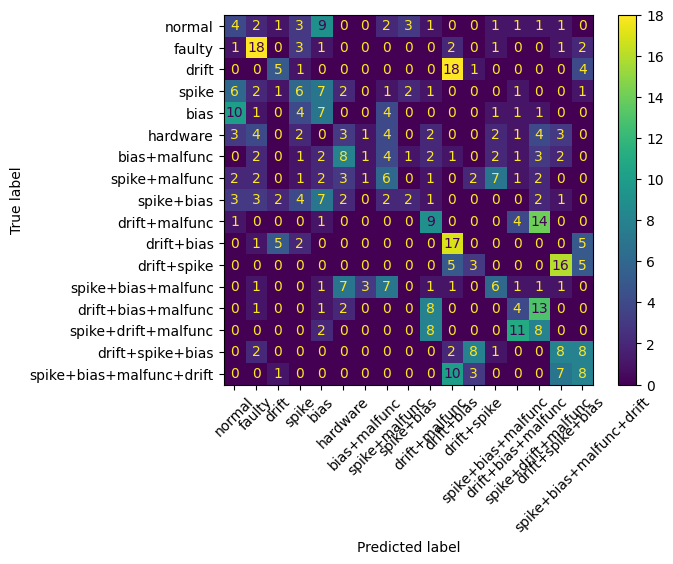

In [33]:

best = gs.best_estimator_
pred = best.predict(Xte)

print(classification_report(yte, pred, labels=np.arange(len(scenario_names)), target_names=scenario_names))
print('Accuracy:', accuracy_score(yte, pred))
print('Macro-F1:', f1_score(yte, pred, average="macro"))
cm = confusion_matrix(yte, pred, labels=np.arange(len(scenario_names)))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=scenario_names)
disp.plot(xticks_rotation=45)
plt.show()


## Arsitektur ANN yang menghasilkan Precision–Recall–F1 Score

Skor **Precision/Recall/F1** di atas berasal dari **model ANN terbaik** hasil *Grid Search* (`gs.best_estimator_`), yaitu pipeline:

`StandardScaler → MLPClassifier`

Arsitekturnya dapat dituliskan sebagai:

- **Jumlah node input (I)** = jumlah fitur pada vektor entropy `F` (kolom pada `Xtr`)
- **Hidden layer** = `hidden_layer_sizes` dari MLP terbaik (bisa 1 atau 2 hidden layer sesuai kandidat grid)
- **Jumlah node output (O)** = jumlah kelas fault (`len(mlp.classes_)`)

Di bawah ini ditampilkan ringkasan arsitektur + visualisasi skematik dan grafik Precision/Recall/F1 per kelas.


=== Arsitektur ANN terbaik (hasil Grid Search) ===
Input layer : 24 node
Hidden layer: (48, 24) (jumlah layer = 2)
Output layer: 17 node (kelas = [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16)])
Activation  : tanh
Alpha (L2)  : 0.0001
LR init     : 0.001


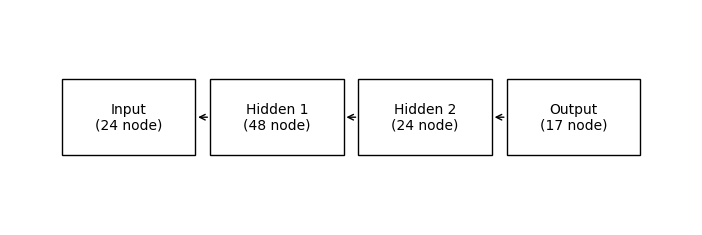

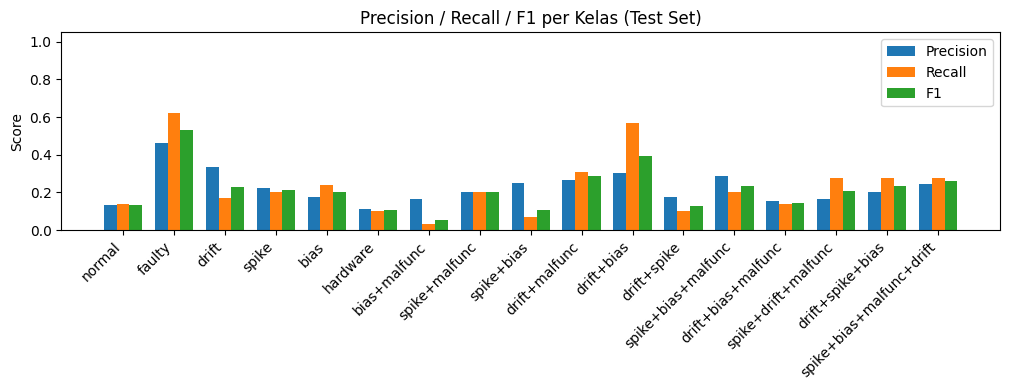

In [34]:
from sklearn.metrics import classification_report, precision_recall_fscore_support

best = gs.best_estimator_
mlp = best.named_steps["mlp"]

I = Xtr.shape[1]
hidden = mlp.hidden_layer_sizes if isinstance(mlp.hidden_layer_sizes, tuple) else (mlp.hidden_layer_sizes,)
O = len(mlp.classes_)

print("=== Arsitektur ANN terbaik (hasil Grid Search) ===")
print(f"Input layer : {I} node")
print(f"Hidden layer: {hidden} (jumlah layer = {len(hidden)})")
print(f"Output layer: {O} node (kelas = {list(mlp.classes_)})")
print("Activation  :", mlp.activation)
print("Alpha (L2)  :", mlp.alpha)
print("LR init     :", mlp.learning_rate_init)

# --- Visualisasi skema arsitektur (ringkas) ---
def plot_mlp_schema(I, hidden, O):
    layers = [("Input", I)] + [(f"Hidden {k+1}", h) for k,h in enumerate(hidden)] + [("Output", O)]
    n = len(layers)
    fig, ax = plt.subplots(figsize=(min(12, 2.2*n), 2.8))
    ax.axis("off")
    xs = list(range(n))
    for i,(name,size) in enumerate(layers):
        ax.add_patch(plt.Rectangle((xs[i]-0.45, -0.35), 0.9, 0.7, fill=False))
        ax.text(xs[i], 0.0, f"{name}\n({size} node)", ha="center", va="center")
        if i < n-1:
            ax.annotate("", xy=(xs[i+1]-0.55, 0), xytext=(xs[i]+0.55, 0), arrowprops=dict(arrowstyle="->"))
    ax.set_xlim(-0.8, n-0.2)
    ax.set_ylim(-1, 1)
    plt.show()

plot_mlp_schema(I, hidden, O)

# --- Visualisasi Precision / Recall / F1 per kelas ---
rep = classification_report(yte, pred, labels=np.arange(len(scenario_names)), target_names=scenario_names, output_dict=True, zero_division=0)
classes = [c for c in scenario_names if c in rep]
prec = [rep[c]["precision"] for c in classes]
rec  = [rep[c]["recall"] for c in classes]
f1   = [rep[c]["f1-score"] for c in classes]

x = np.arange(len(classes))
w = 0.25
plt.figure(figsize=(max(10, 0.6*len(classes)), 4))
plt.bar(x - w, prec, width=w, label="Precision")
plt.bar(x,     rec,  width=w, label="Recall")
plt.bar(x + w, f1,   width=w, label="F1")
plt.xticks(x, classes, rotation=45, ha="right")
plt.ylim(0, 1.05)
plt.ylabel("Score")
plt.title("Precision / Recall / F1 per Kelas (Test Set)")
plt.legend()
plt.tight_layout()
plt.show()


In [35]:

# Baseline comparisons (trained on same split as ANN)
baseline_lr = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=2000, multi_class="auto"))
])

baseline_rf = RandomForestClassifier(
    n_estimators=400,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced_subsample"
)

results = []
# ANN best estimator
results.append({
    "model":"ANN (GridSearch best)",
    "accuracy": float(accuracy_score(yte, pred)),
    "macro_f1": float(f1_score(yte, pred, average="macro"))
})
results.append(eval_model("LogReg", baseline_lr, Xtr, ytr, Xte, yte))
results.append(eval_model("RandomForest", baseline_rf, Xtr, ytr, Xte, yte))

pd.DataFrame(results).sort_values(["macro_f1","accuracy"], ascending=False)


/home/juripebrianto/.local/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


,model,accuracy,macro_f1
1,LogReg,0.251004,0.244910
0,ANN (GridSearch best),0.230924,0.215520
2,RandomForest,0.214859,0.210262


In [36]:

# === Per-scenario ANN architecture search (accuracy vs compute cost) ===

import numpy as np
from sklearn.impute import SimpleImputer
from sklearn.model_selection import StratifiedKFold

# Helpers

def count_mlp_params(I, hidden, O):
    sizes = [I] + list(hidden) + [O]
    return int(sum((sizes[i] + 1) * sizes[i+1] for i in range(len(sizes)-1)))

def balanced_binary_subsample(X, y, max_per_class=300, seed=0):
    rng = np.random.default_rng(seed)
    keep = []
    for c in [0, 1]:
        idx = np.where(y == c)[0]
        if len(idx) > max_per_class:
            idx = rng.choice(idx, size=max_per_class, replace=False)
        keep.append(idx)
    keep = np.concatenate(keep)
    rng.shuffle(keep)
    return X[keep], y[keep]

def small_arch_candidates(I, O, max_cand=10):
    base = sorted(set([
        max(8, I//4),
        max(16, I//2),
        max(32, int(np.floor((2/3)*I + O))),
        I,
        min(2*I, 256),
    ]))
    cand = [(h,) for h in base]
    for h1 in base[:3]:
        cand.append((h1, max(8, h1//2)))
    cand = list(dict.fromkeys(cand))[:max_cand]
    return cand

def fit_best_mlp(X, y, seed=42, max_iter=250, cv=3):
    # Impute + scale always, to avoid NaN errors
    pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("mlp", MLPClassifier(
            random_state=seed,
            max_iter=max_iter,
            early_stopping=True,
            n_iter_no_change=10
        ))
    ])
    I = X.shape[1]
    O = len(np.unique(y))
    candidates = small_arch_candidates(I, O, max_cand=SCENARIO_MAX_CANDIDATES)
    param_grid = {
        "mlp__hidden_layer_sizes": candidates,
        "mlp__alpha": [1e-4, 1e-3],
        "mlp__learning_rate_init": [1e-3],
        "mlp__activation": ["relu", "tanh"],
    }
    cv = StratifiedKFold(n_splits=cv, shuffle=True, random_state=seed)
    gs = GridSearchCV(pipe, param_grid=param_grid, cv=cv, n_jobs=1, scoring="f1_macro", verbose=0)
    t0 = time.perf_counter()
    gs.fit(X, y)
    t1 = time.perf_counter()
    return gs, (t1 - t0)

# Build per-scenario datasets (binary: normal vs scenario)
scenario_results = []

if "F" not in globals() or "y_s" not in globals():
    print("F/y_s belum tersedia. Jalankan cell fitur terlebih dahulu.")
else:
    for k, name in enumerate(scenario_names):
        if name == "normal":
            continue
        if time_left_sec() is not None and time_left_sec() < 600:
            print("Time budget hampir habis, menghentikan per-scenario search.")
            break

        mask = (y_s == 0) | (y_s == k)
        X_bin = F[mask]
        y_bin = (y_s[mask] == k).astype(int)

        # Balanced subsample for speed + class balance
        X_bin, y_bin = balanced_binary_subsample(X_bin, y_bin, max_per_class=SCENARIO_MAX_PER_CLASS, seed=RANDOM_SEED + k)

        # Train/test split
        Xtr, Xte, ytr, yte = train_test_split(
            X_bin, y_bin, test_size=SCENARIO_TEST_FRAC, random_state=RANDOM_SEED, stratify=y_bin
        )

        # Grid search (best architecture)
        gs, wall_s = fit_best_mlp(Xtr, ytr, seed=RANDOM_SEED, max_iter=SCENARIO_MAX_ITER, cv=SCENARIO_GRID_CV)
        best = gs.best_estimator_
        pred = best.predict(Xte)
        f1 = f1_score(yte, pred, average="macro")
        acc = accuracy_score(yte, pred)

        mlp = best.named_steps["mlp"]
        hidden = mlp.hidden_layer_sizes if isinstance(mlp.hidden_layer_sizes, tuple) else (mlp.hidden_layer_sizes,)
        I = Xtr.shape[1]
        O = len(np.unique(y_bin))
        params = count_mlp_params(I, hidden, O)

        # Inference time proxy (per 1000 samples)
        t0 = time.perf_counter()
        _ = best.predict(Xte[:min(1000, len(Xte))])
        t1 = time.perf_counter()
        inf_ms_per_sample = (t1 - t0) * 1000.0 / max(1, min(1000, len(Xte)))

        scenario_results.append({
            "scenario": name,
            "n_train": int(len(Xtr)),
            "n_test": int(len(Xte)),
            "best_hidden": str(hidden),
            "activation": mlp.activation,
            "alpha": float(mlp.alpha),
            "lr_init": float(mlp.learning_rate_init),
            "cv_f1": float(gs.best_score_),
            "test_f1": float(f1),
            "test_acc": float(acc),
            "params": params,
            "train_wall_s": float(wall_s),
            "inf_ms_per_sample": float(inf_ms_per_sample),
        })

scenario_table = pd.DataFrame(scenario_results)
scenario_table


,scenario,n_train,n_test,best_hidden,activation,alpha,lr_init,cv_f1,test_f1,test_acc,params,train_wall_s,inf_ms_per_sample
0,faulty,175,59,"(32,)",tanh,0.0001,0.001,0.716530,0.615814,0.644068,866,0.740864,0.003957
1,drift,175,59,"(24, 12)",relu,0.0001,0.001,0.868505,0.915157,0.915254,926,0.791428,0.003988
2,spike,175,59,"(24,)",tanh,0.0001,0.001,0.556321,0.410000,0.423729,650,0.646362,0.003774
3,bias,175,59,"(32,)",relu,0.0001,0.001,0.513726,0.404040,0.406780,866,0.604965,0.003749
4,hardware,175,59,"(24, 12)",tanh,0.0001,0.001,0.654766,0.724942,0.728814,926,0.805351,0.003942
5,bias+malfunc,175,59,"(32,)",relu,0.0001,0.001,0.706117,0.593103,0.593220,866,0.829758,0.003792
6,spike+malfunc,175,59,"(24, 12)",tanh,0.0001,0.001,0.679867,0.671934,0.677966,926,0.790334,0.003947
7,spike+bias,175,59,"(24, 12)",relu,0.0001,0.001,0.513467,0.499268,0.508475,926,0.606343,0.003887
8,drift+malfunc,175,59,"(24, 12)",tanh,0.0001,0.001,0.760328,0.750604,0.762712,926,0.788601,0.004054
9,drift+bias,175,59,"(24,)",relu,0.0001,0.001,0.849390,0.673833,0.694915,650,0.777094,0.003757


# Eksperimen Sensitivitas Jumlah Skala `S`

`run_experiment_S(...)`

**Tujuan:** melihat trade-off:
- Stabilitas entropy (CV) vs
- Performa klasifikasi (Accuracy/Macro-F1)
ketika `S` diubah.

**Proses per nilai S**
1) Hitung fitur `F` dengan ukuran `4*S`
2) Hitung `CV_mean` (rata-rata cv_avg)
3) Train MLP sederhana (tanpa grid besar) untuk estimasi performa
4) Simpan ringkasan ke tabel `exp`

**Output**
- `exp`: DataFrame berisi kolom `S, CV_mean, test_acc, macro_f1, I, H1`
- Plot CV vs S, Accuracy vs S, Macro-F1 vs S


## 8) Eksperimen: variasi jumlah skala `S` (untuk CV + akurasi)
Bagian ini mengulang pipeline fitur untuk beberapa `S` agar terlihat hubungan kestabilan (CV) dan performa klasifikasi.

Untuk speed: turunkan `MAX_PER_CLASS`, `n_ref`, atau `S_list`.

In [37]:
def run_experiment_S(W, y, S_list=(5,8,10,12), m=2, r_ratio=0.2, n_ref=128, seed=7, use_time_split=False, method="EDM-Fuzzy"):
    rows=[]
    for S in S_list:
        scales=np.arange(1,S+1)
        if method is None:
            method = DEFAULT_METHOD
        F = compute_features_entropy(W, scales=scales, method=method, m=m, r_ratio=r_ratio, n_ref=n_ref, seed=seed)
        Fdf=pd.DataFrame(F).fillna(pd.DataFrame(F).median(numeric_only=True))
        F=Fdf.to_numpy()
        cv_by_sensor, cv_avg = entropy_cv_report(F, S=S)

        # simple MLP (no big grid) for quick trend
        Xtr, Xte, ytr, yte = time_split(F, y, test_frac=0.25) if use_time_split else train_test_split(F, y, test_size=0.25, random_state=42, stratify=y)
        I = F.shape[1]
        O = len(np.unique(y))
        H1 = int(np.floor((2/3)*I + O))

        clf = Pipeline([
            ("scaler", StandardScaler()),
            ("mlp", MLPClassifier(hidden_layer_sizes=(H1,), max_iter=200, random_state=42))
        ])
        clf.fit(Xtr, ytr)
        pred = clf.predict(Xte)
        rows.append({
            "S": S,
            "CV_mean": float(np.mean(cv_avg)),
            "test_acc": float(accuracy_score(yte, pred)),
            "macro_f1": float(f1_score(yte, pred, average="macro")),
            "I": I,
            "H1": H1,
            "method": method
        })

    exp = pd.DataFrame(rows)
    return exp


/home/juripebrianto/.local/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/juripebrianto/.local/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/juripebrianto/.local/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/juripebrianto/.local/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


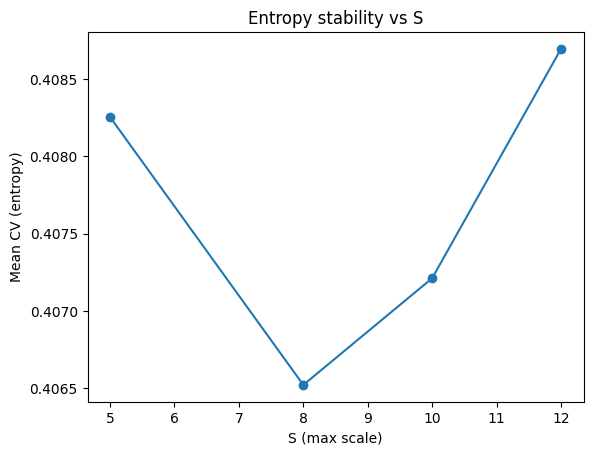

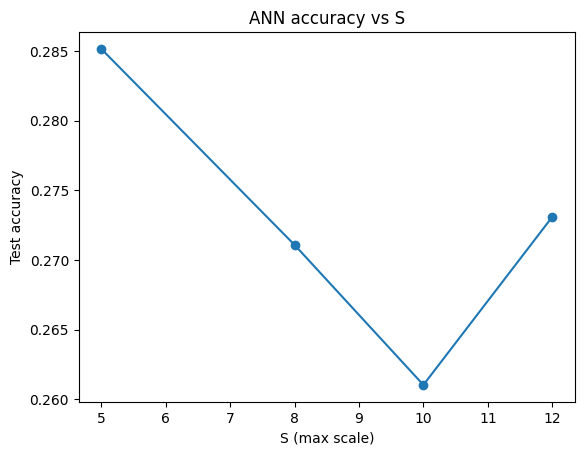

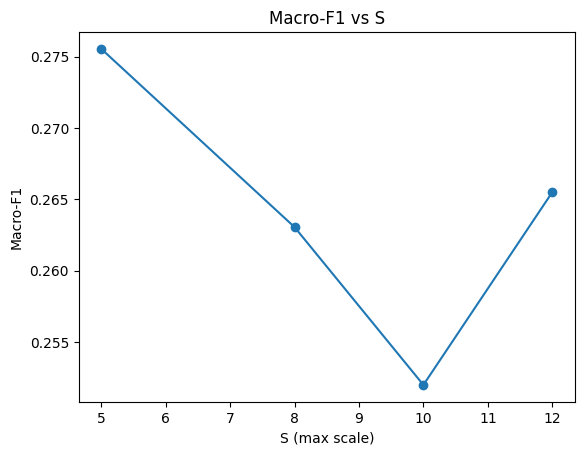

In [38]:

# === Robust experiment computation (fully self-contained, no NameError) ===

if "S_list" not in globals():
    S_list = (5, 8, 10, 12)

if "exp" not in globals():
    exp = run_experiment_S(
        W_s, y_s,
        S_list=S_list,
        m=2,
        r_ratio=0.2,
        n_ref=128,
        seed=7,
        use_time_split=USE_TIME_SPLIT
    )

# ---- Plotcs ----
plt.figure()
plt.plot(exp["S"], exp["CV_mean"], marker="o")
plt.xlabel("S (max scale)")
plt.ylabel("Mean CV (entropy)")
plt.title("Entropy stability vs S")
plt.show()

plt.figure()
plt.plot(exp["S"], exp["test_acc"], marker="o")
plt.xlabel("S (max scale)")
plt.ylabel("Test accuracy")
plt.title("ANN accuracy vs S")
plt.show()

plt.figure()
plt.plot(exp["S"], exp["macro_f1"], marker="o")
plt.xlabel("S (max scale)")
plt.ylabel("Macro-F1")
plt.title("Macro-F1 vs S")
plt.show()


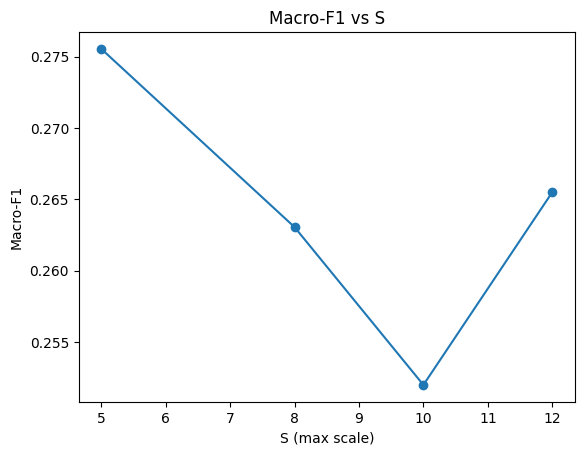

In [39]:

plt.figure()
plt.plot(exp["S"], exp["macro_f1"], marker='o')
plt.xlabel("S (max scale)")
plt.ylabel("Macro-F1")
plt.title("Macro-F1 vs S")
plt.show()


In [40]:
# Export all key tables (CSV + Parquet) with clickable links
export_df(feature_metrics_table, "feature_metrics_table", index=True)
export_df(train_metrics_table, "train_metrics_table", index=True)
export_df(combined_metrics_table, "combined_metrics_table", index=True)
if "cv_table" in globals():
    export_df(cv_table, "cv_table", index=False)
if "mean_entropy_table" in globals():
    export_df(mean_entropy_table, "mean_entropy_table", index=True)
if "exp" in globals():
    export_df(exp, "experiment_S_table", index=False)
if "scenario_table" in globals():
    export_df(scenario_table, "scenario_ann_tradeoff_table", index=False)


/home/juripebrianto/luh-kesuma/exports/feature_metrics_table.csv

/home/juripebrianto/luh-kesuma/exports/feature_metrics_table.parquet

/home/juripebrianto/luh-kesuma/exports/train_metrics_table.csv

/home/juripebrianto/luh-kesuma/exports/train_metrics_table.parquet

/home/juripebrianto/luh-kesuma/exports/combined_metrics_table.csv

...

/home/juripebrianto/luh-kesuma/exports/mean_entropy_table.parquet

/home/juripebrianto/luh-kesuma/exports/experiment_S_table.csv

/home/juripebrianto/luh-kesuma/exports/experiment_S_table.parquet

/home/juripebrianto/luh-kesuma/exports/scenario_ann_tradeoff_table.csv

/home/juripebrianto/luh-kesuma/exports/scenario_ann_tradeoff_table.parquet

### Notes (what to adjust next run)

**Main switches**
- `FAST_MODE`: fastest end-to-end run (smaller sampling + lighter ANN search). Set `False` for more thorough accuracy runs.
- `RUN_ALL_METHODS`: compute/evaluate all entropy methods in `METHOD_LIST`.
- `DEFAULT_METHOD`: which method is used for the “single-method” plots/reports when you only want one highlighted.

**Speed knobs**
- `MAX_PER_CLASS`, `WIN`, `STRIDE`, `S`, `n_ref`: biggest impact on runtime (entropy dominates).
- If you re-run often, keep `CACHE_FEATURES=True` so features load from `cache/` instead of recomputing.

**Quality knobs**
- Increase `MAX_PER_CLASS`, `S`, and `n_ref` for better estimates (slower).
- Turn on `USE_TIME_SPLIT=True` to reduce leakage when windows overlap (may lower apparent accuracy but is more honest).
- Expand `param_grid` (hidden sizes / alpha / lr / activation) for a stronger ANN search (slower).

**Export**
All important tables are saved to `exports/` as CSV (and Parquet when available) with clickable links in the last cell.
